# LSGNN — data analysis notebook

Use this notebook to validate the runtime environment, summarize processed datasets, and analyze model outputs from saved checkpoints.

Sections: environment checks, dataset statistics, then output analysis with forward pass and plots.

In [1]:
import os
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
if (_cwd / "src").is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / "src").is_dir():
    REPO_ROOT = _cwd.parent
else:
    raise RuntimeError(
        f"Project root not found (expected a directory containing src/). cwd={_cwd}. "
        "Open the notebook from the repo root or from notebooks/, then re-run this cell."
    )

os.chdir(REPO_ROOT)
_root_s = str(REPO_ROOT)
if _root_s not in sys.path:
    sys.path.insert(0, _root_s)

print("REPO_ROOT =", REPO_ROOT)
print("cwd       =", Path.cwd())

REPO_ROOT = /home/zhaog30/cas_747/Guanhua_Zhao
cwd       = /home/zhaog30/cas_747/Guanhua_Zhao


## Environment check

Verify Python, PyTorch, CUDA, and PyG-related packages in the current kernel before running analysis.

In [2]:
import importlib

import torch

print("python   ", sys.version.split()[0])
print("torch    ", torch.__version__, "| cuda", torch.version.cuda)
print("cuda ok? ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device   ", torch.cuda.get_device_name(0))

for mod in ("torch_geometric", "torch_sparse", "torch_scatter"):
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, "__version__", "?")
        print(f"{mod:16s}", ver)
    except Exception as e:
        print(f"{mod:16s}", "IMPORT FAILED:", e)

python    3.11.15
torch     2.11.0+cu128 | cuda 12.8
cuda ok?  True
device    NVIDIA GeForce RTX 5070
torch_geometric  2.7.0
torch_sparse     0.6.18+pt211cu128
torch_scatter    2.1.2+pt211cu128


## Dataset analysis (no model forward)

This section analyzes dataset structure only.

Supported dataset names:

`actor`, `arxiv-year`, `chameleon`, `citeseer`, `cornell`, `cora`, `ogbn-arxiv`, `pubmed`, `squirrel`, `texas`, `wisconsin`

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import torch

from src.data_processing.io import load_processed, with_split

DATASET = "cora"
SPLIT_IDX = 0

processed_pt = REPO_ROOT / "data" / "processed" / f"{DATASET}.pt"
if processed_pt.is_file():
    print("found:", processed_pt)
else:
    print("running preprocess...")
    subprocess.run(
        [sys.executable, "-m", "src.data_processing.preprocess", "--dataset", DATASET],
        cwd=REPO_ROOT,
        check=True,
    )
    print("done:", processed_pt)

data_full = load_processed(DATASET)
data = with_split(data_full, SPLIT_IDX)

x = data["x"]
y = data["y"].view(-1)
edge_index = data["edge_index"]
train_mask = data["train_mask"].view(-1)
val_mask = data["val_mask"].view(-1)
test_mask = data["test_mask"].view(-1)
num_classes = int(data["num_classes"])

print(f"dataset={DATASET} split_idx={SPLIT_IDX}")
print(f"x shape={tuple(x.shape)}")
print(f"y shape={tuple(y.shape)}")
print(f"edge_index shape={tuple(edge_index.shape)}")
print(f"num_classes={num_classes}")

dataset=cora split_idx=0
x shape=(2708, 1433)
y shape=(2708,)
edge_index shape=(2, 10556)
num_classes=7


In [4]:
num_nodes = int(x.size(0))
num_edges = int(edge_index.size(1))
num_features = int(x.size(1))

def _count(mask):
    return int(mask.sum().item())

n_train = _count(train_mask)
n_val = _count(val_mask)
n_test = _count(test_mask)

print(f"num_nodes={num_nodes}")
print(f"num_edges={num_edges}")
print(f"num_features={num_features}")
print(f"train={n_train} ({n_train / num_nodes:.2%})")
print(f"val={n_val} ({n_val / num_nodes:.2%})")
print(f"test={n_test} ({n_test / num_nodes:.2%})")
print(f"avg_degree_directed={num_edges / num_nodes:.3f}")
print(f"avg_degree_undirected_approx={2.0 * num_edges / num_nodes:.3f}")

num_nodes=2708
num_edges=10556
num_features=1433
train=1304 (48.15%)
val=867 (32.02%)
test=537 (19.83%)
avg_degree_directed=3.898
avg_degree_undirected_approx=7.796


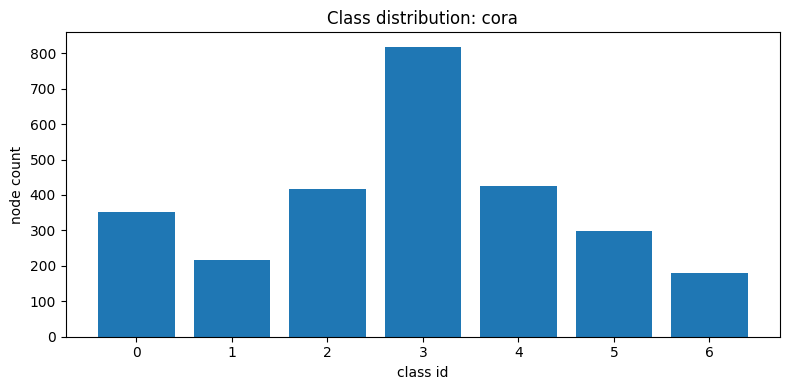

In [5]:
class_counts = torch.bincount(y, minlength=num_classes).cpu().numpy()
class_ids = np.arange(num_classes)

plt.figure(figsize=(8, 4))
plt.bar(class_ids, class_counts)
plt.xticks(class_ids)
plt.xlabel("class id")
plt.ylabel("node count")
plt.title(f"Class distribution: {DATASET}")
plt.tight_layout()
plt.show()

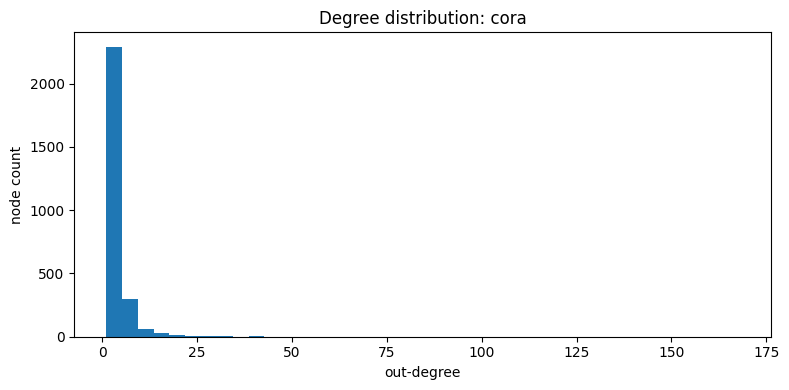

degree quantiles p50=3.0 p90=7.0 p95=9.0 p99=19.0


In [6]:
deg = torch.bincount(edge_index[0], minlength=num_nodes).cpu().numpy()

plt.figure(figsize=(8, 4))
plt.hist(deg, bins=40)
plt.xlabel("out-degree")
plt.ylabel("node count")
plt.title(f"Degree distribution: {DATASET}")
plt.tight_layout()
plt.show()

q = np.quantile(deg, [0.5, 0.9, 0.95, 0.99])
print(
    f"degree quantiles p50={q[0]:.1f} p90={q[1]:.1f} p95={q[2]:.1f} p99={q[3]:.1f}"
)

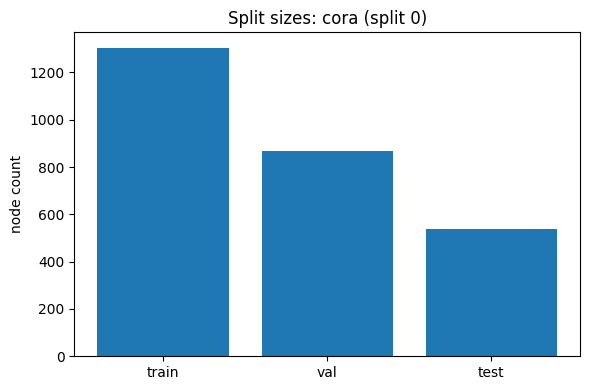

In [7]:
split_names = ["train", "val", "test"]
split_counts = np.array([n_train, n_val, n_test])

plt.figure(figsize=(6, 4))
plt.bar(split_names, split_counts)
plt.ylabel("node count")
plt.title(f"Split sizes: {DATASET} (split {SPLIT_IDX})")
plt.tight_layout()
plt.show()

## Output analysis (trained checkpoint)

Set `CKPT_PATH` to a saved checkpoint under `results/model_outputs/<dataset>/` or `results/notebook_model_outputs/<dataset>/`. Use the same `PROCESSED_NAME` as training. If `SPLIT_IDX` is `None`, the split stored in the checkpoint config is used.

This section runs one forward pass and plots test-set behavior.

In [8]:
from sklearn.metrics import confusion_matrix

from src.evaluation.evaluate import evaluate_checkpoint

CKPT_PATH = str(REPO_ROOT / "results" / "model_outputs" / "cora" / "lsgnn_cora_split0_best_acc.ckpt")
PROCESSED_NAME = "cora"
SPLIT_IDX = None

out = evaluate_checkpoint(
    CKPT_PATH,
    PROCESSED_NAME,
    split_idx_override=SPLIT_IDX,
    return_outputs=True,
)
print(
    "dataset",
    out["dataset"],
    "split",
    out["split_idx"],
    "train_acc",
    out["train_acc"],
    "val_acc",
    out["val_acc"],
    "test_acc",
    out["test_acc"],
)

/home/zhaog30/cas_747/Guanhua_Zhao/src/utils/helpers.py:55: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  return torch.sparse.FloatTensor(indices, values, shape)


2026-04-06 17:29:39 INFO [lsgnn.evaluate] checkpoint=lsgnn_cora_split0_best_acc.ckpt dataset=cora train_acc=0.9962 val_acc=0.8766 test_acc=0.8939
dataset cora split 0 train_acc 0.9961656332015991 val_acc 0.8765859007835388 test_acc 0.8938547372817993


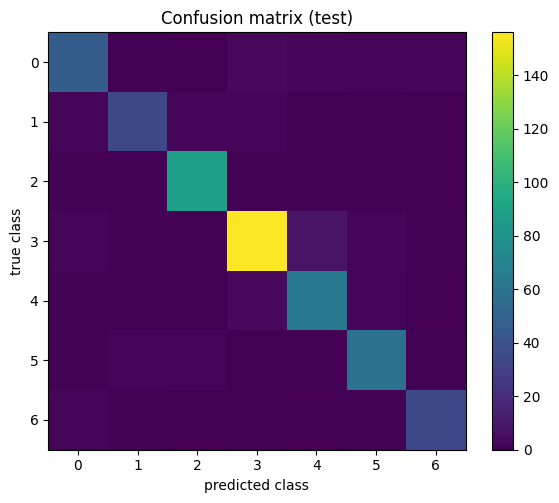

In [9]:
y = out["y"]
preds = out["preds"]
conf = out["conf"]
test_mask = out["test_mask"]
num_classes = int(out["num_classes"])

y_t = y[test_mask].numpy()
p_t = preds[test_mask].numpy()
cm = confusion_matrix(y_t, p_t, labels=np.arange(num_classes))

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.colorbar()
plt.xlabel("predicted class")
plt.ylabel("true class")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.show()

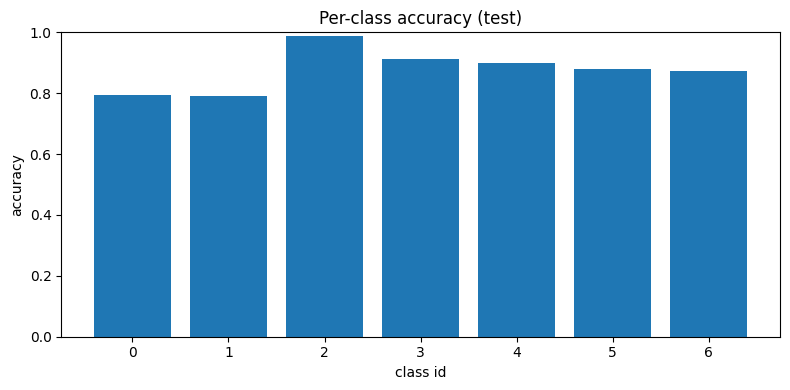

In [10]:
acc_pc = []
for c in range(num_classes):
    m = (y == c) & test_mask
    n = int(m.sum().item())
    if n == 0:
        acc_pc.append(0.0)
    else:
        acc_pc.append(((preds == y) & m).sum().item() / n)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(num_classes), acc_pc)
plt.xticks(np.arange(num_classes))
plt.xlabel("class id")
plt.ylabel("accuracy")
plt.ylim(0.0, 1.0)
plt.title("Per-class accuracy (test)")
plt.tight_layout()
plt.show()

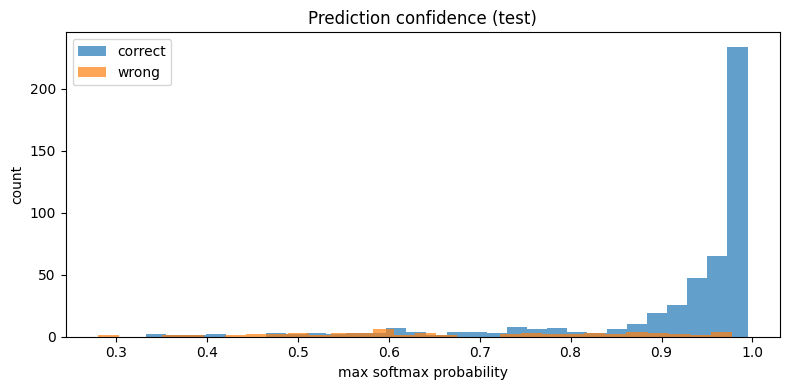

In [11]:
pt = preds[test_mask]
yt = y[test_mask]
cf = conf[test_mask].numpy()
ok = (pt == yt).numpy()

plt.figure(figsize=(8, 4))
plt.hist(cf[ok], bins=30, alpha=0.7, label="correct")
plt.hist(cf[~ok], bins=30, alpha=0.7, label="wrong")
plt.xlabel("max softmax probability")
plt.ylabel("count")
plt.title("Prediction confidence (test)")
plt.legend()
plt.tight_layout()
plt.show()